In [1]:
import pandas as pd
import numpy as np
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import LabelEncoder
from datasets import Dataset
import matplotlib.pyplot as plt
import seaborn as sns
from collections import Counter
import os

os.environ["USE_TF"] = "0"
from transformers import AutoTokenizer, AutoModelForSequenceClassification, Trainer, TrainingArguments, EarlyStoppingCallback
from sklearn.metrics import precision_score, recall_score, accuracy_score, f1_score, classification_report, confusion_matrix
from transformers import TrainingArguments


/home/pierre/miniconda3/envs/ia/lib/python3.9/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


In [2]:
# Variable
percentage_genre_to_keep = 25
test_size = 0.05
random_state = 42

In [3]:
df = pd.read_csv("../../data/MovieDataThread.csv")
index_drop = df.loc[df['imdb_id'].isnull()].index
df = df.drop(index=index_drop)
df = df.drop(columns=['imdb_id'])
df_filtered = pd.concat([df[['Script','Title']],df.filter(like='imdb_')],axis=1)
df_filtered["genre_count"] = df_filtered.filter(regex='^imdb_(?!id$)').count(axis=1)
df_filtered_one_genre = df_filtered.loc[df_filtered['genre_count'] == 1]
df_filtered_one_genre['filtered_genre'] = df_filtered_one_genre.apply(lambda row: next(iter([col for col in df_filtered_one_genre.columns if "imdb" in col and row[col] == 1.0 ]), 'unknown'), axis=1)
number_genres = len(df_filtered_one_genre['filtered_genre'].unique())
counter = Counter(df_filtered_one_genre['filtered_genre'])
sorted_list = sorted(counter.items(),reverse=True , key=lambda genre : genre[1])[: int(number_genres * (percentage_genre_to_keep / 100))]

genre_to_keep = [genre for genre,_ in sorted_list]
columns_to_keep = ['Script','filtered_genre']

df_movies = df_filtered_one_genre.loc[df_filtered_one_genre['filtered_genre'].isin(genre_to_keep)]
df_movies = df_movies[columns_to_keep].reset_index(drop=True)


/tmp/ipykernel_8605/1322963480.py:8: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  df_filtered_one_genre['filtered_genre'] = df_filtered_one_genre.apply(lambda row: next(iter([col for col in df_filtered_one_genre.columns if "imdb" in col and row[col] == 1.0 ]), 'unknown'), axis=1)


In [4]:
X = df_movies['Script']
y = df_movies['filtered_genre']


Map: 100%|██████████| 386/386 [00:00<00:00, 2928.18 examples/s]
Some weights of BertForSequenceClassification were not initialized from the model checkpoint at sentence-transformers/all-MiniLM-L6-v2 and are newly initialized: ['classifier.bias', 'classifier.weight']
You should probably TRAIN this model on a down-stream task to be able to use it for predictions and inference.
/home/pierre/miniconda3/envs/ia/lib/python3.9/site-packages/transformers/training_args.py:1474: FutureWarning: `evaluation_strategy` is deprecated and will be removed in version 4.46 of 🤗 Transformers. Use `eval_strategy` instead
  warnings.warn(
huggingface/tokenizers: The current process just got forked, after parallelism has already been used. Disabling parallelism to avoid deadlocks...
To disable this warning, you can either:
	- Avoid using `tokenizers` before the fork if possible
	- Explicitly set the environment variable TOKENIZERS_PARALLELISM=(true | false)
2025-05-10 11:20:03.163703: I tensorflow/core/util/

Epoch,Training Loss,Validation Loss,Precision,Recall,Accuracy,F1
1,1.322900,1.178043,0.483022,0.562176,0.562176,0.486574
2,1.128100,1.059628,0.653413,0.639896,0.639896,0.621416
3,1.036000,1.036975,0.645135,0.629534,0.629534,0.622730
4,0.933800,1.041920,0.633416,0.647668,0.647668,0.628452
5,0.860400,1.090050,0.648343,0.629534,0.629534,0.629176
6,0.774100,1.154478,0.648618,0.647668,0.647668,0.644700


/home/pierre/miniconda3/envs/ia/lib/python3.9/site-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))


                  precision    recall  f1-score   support

     imdb_comedy       0.61      0.53      0.57        73
imdb_documentary       0.78      0.83      0.81        65
      imdb_drama       0.69      0.77      0.73       162
     imdb_horror       0.46      0.63      0.53        43
    imdb_romance       0.44      0.27      0.33        15
   imdb_thriller       0.40      0.07      0.12        28

        accuracy                           0.65       386
       macro avg       0.56      0.52      0.51       386
    weighted avg       0.63      0.65      0.63       386



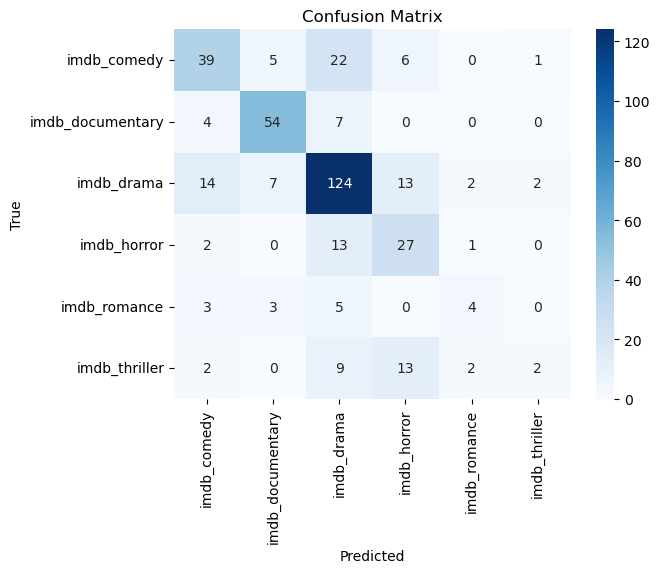

In [5]:
X = X.apply(lambda x: ' '.join(str(x).split()[:512]))

label_encoder = LabelEncoder()
y_encoded = label_encoder.fit_transform(y)

train_texts, test_texts, train_labels, test_labels = train_test_split(X, y_encoded, test_size=test_size, random_state=random_state)

train_dataset = Dataset.from_dict({'text': train_texts, 'label': train_labels})
test_dataset = Dataset.from_dict({'text': test_texts, 'label': test_labels})

model_checkpoint = "sentence-transformers/all-MiniLM-L6-v2"
tokenizer = AutoTokenizer.from_pretrained(model_checkpoint)

def tokenize_function(examples):
    return tokenizer(examples["text"], padding="max_length", truncation=True, max_length=512)

train_dataset = train_dataset.map(tokenize_function, batched=True)
test_dataset = test_dataset.map(tokenize_function, batched=True)

train_dataset = train_dataset.remove_columns(["text"])
test_dataset = test_dataset.remove_columns(["text"])
train_dataset.set_format("torch")
test_dataset.set_format("torch")

model = AutoModelForSequenceClassification.from_pretrained(
    model_checkpoint,
    num_labels=len(label_encoder.classes_)
)

def compute_metrics(eval_pred):
    logits, labels = eval_pred
    predictions = np.argmax(logits, axis=-1)
    return {
        'precision': precision_score(labels, predictions, average='weighted'),
        'recall': recall_score(labels, predictions, average='weighted'),
        'accuracy': accuracy_score(labels, predictions),
        'f1': f1_score(labels, predictions, average='weighted')
    }

training_args = TrainingArguments(
    output_dir="./results",
    evaluation_strategy="epoch",
    save_strategy="epoch",
    learning_rate=1e-5,
    per_device_train_batch_size=4,
    per_device_eval_batch_size=4,
    num_train_epochs=10,
    weight_decay=0.01,
    load_best_model_at_end=True,
    metric_for_best_model="accuracy",
    fp16=True
)


trainer = Trainer(
    model=model,
    args=training_args,
    train_dataset=train_dataset,
    eval_dataset=test_dataset,
    tokenizer=tokenizer,
    compute_metrics=compute_metrics,
    callbacks=[EarlyStoppingCallback(early_stopping_patience=2)]
)

trainer.train()

predictions = trainer.predict(test_dataset)
y_preds = np.argmax(predictions.predictions, axis=1)

print(classification_report(test_labels, y_preds, target_names=label_encoder.classes_))
cm = confusion_matrix(test_labels, y_preds)
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', xticklabels=label_encoder.classes_, yticklabels=label_encoder.classes_)
plt.xlabel('Predicted')
plt.ylabel('True')
plt.title('Confusion Matrix')
plt.show()

In [6]:
model.save_pretrained("./results")
tokenizer.save_pretrained("./results")


('./results/tokenizer_config.json',
 './results/special_tokens_map.json',
 './results/vocab.txt',
 './results/added_tokens.json',
 './results/tokenizer.json')

# Augmentation data

In [2]:
import pandas as pd
import random
import nltk
from nltk.corpus import wordnet
from nltk.tokenize import word_tokenize
from nltk.corpus import stopwords

nltk.download('punkt')
nltk.download('punkt_tab')
nltk.download('stopwords')
nltk.download('wordnet')
nltk.download('averaged_perceptron_tagger_eng')

[nltk_data] Downloading package punkt to /home/pierre/nltk_data...
[nltk_data]   Package punkt is already up-to-date!
[nltk_data] Downloading package punkt_tab to /home/pierre/nltk_data...
[nltk_data]   Package punkt_tab is already up-to-date!
[nltk_data] Downloading package stopwords to /home/pierre/nltk_data...
[nltk_data]   Package stopwords is already up-to-date!
[nltk_data] Downloading package wordnet to /home/pierre/nltk_data...
[nltk_data]   Package wordnet is already up-to-date!
[nltk_data] Downloading package averaged_perceptron_tagger_eng to
[nltk_data]     /home/pierre/nltk_data...
[nltk_data]   Package averaged_perceptron_tagger_eng is already up-to-
[nltk_data]       date!


True

In [3]:
percentage_genre_to_keep = 25
test_size = 0.2
random_state = 42

In [4]:
df = pd.read_csv("../../data/MovieDataThread.csv")
index_drop = df.loc[df['imdb_id'].isnull()].index
df = df.drop(index=index_drop)
df = df.drop(columns=['imdb_id'])
df_filtered = pd.concat([df[['Script','Title']],df.filter(like='imdb_')],axis=1)
df_filtered["genre_count"] = df_filtered.filter(regex='^imdb_(?!id$)').count(axis=1)
df_filtered_one_genre = df_filtered.loc[df_filtered['genre_count'] == 1]
df_filtered_one_genre['filtered_genre'] = df_filtered_one_genre.apply(lambda row: next(iter([col for col in df_filtered_one_genre.columns if "imdb" in col and row[col] == 1.0 ]), 'unknown'), axis=1)
number_genres = len(df_filtered_one_genre['filtered_genre'].unique())
counter = Counter(df_filtered_one_genre['filtered_genre'])
sorted_list = sorted(counter.items(),reverse=True , key=lambda genre : genre[1])[: int(number_genres * (percentage_genre_to_keep / 100))]

genre_to_keep = [genre for genre,_ in sorted_list]
columns_to_keep = ['Script','filtered_genre']

df_movies= df_filtered_one_genre.loc[df_filtered_one_genre['filtered_genre'].isin(genre_to_keep)]
df_movies = df_movies[columns_to_keep].reset_index(drop=True)

/tmp/ipykernel_29187/1532818558.py:8: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  df_filtered_one_genre['filtered_genre'] = df_filtered_one_genre.apply(lambda row: next(iter([col for col in df_filtered_one_genre.columns if "imdb" in col and row[col] == 1.0 ]), 'unknown'), axis=1)


In [5]:
X = df_movies['Script']
y = df_movies['filtered_genre']

In [12]:
X = X.apply(lambda x: ' '.join(str(x).split()[:512]))

train_texts, test_texts, train_labels, test_labels = train_test_split(X, y, test_size=test_size, random_state=42)

In [13]:
len(train_texts), len(train_labels)

(6176, 6176)

## Synonym

In [13]:
# Perform augmentation
stop_words = set(stopwords.words("english"))

# Mapping NLTK POS → WordNet POS
def get_wordnet_pos(tag):
    if tag.startswith('J'):
        return wordnet.ADJ
    elif tag.startswith('V'):
        return wordnet.VERB
    elif tag.startswith('N'):
        return wordnet.NOUN
    elif tag.startswith('R'):
        return wordnet.ADV
    else:
        return None

def get_synonym(word, tag):
    wn_tag = get_wordnet_pos(tag)
    if wn_tag is None:
        return word

    synsets = wordnet.synsets(word, pos=wn_tag)
    if not synsets:
        return word

    lemmas = [lemma.name().replace("_", " ") for syn in synsets for lemma in syn.lemmas()
              if lemma.name().lower() != word.lower()]
    return random.choice(lemmas) if lemmas else word

def synonym_augment(text):
    words = word_tokenize(text)
    tagged_words = nltk.pos_tag(words)
    new_words = []

    for word, tag in tagged_words:
        if word.lower() not in stop_words and word.isalpha():
            synonym = get_synonym(word, tag)
            new_words.append(synonym)
        else:
            new_words.append(word)

    return ' '.join(new_words)

# Augment underrepresented genres
thriller_romance_indices = train_labels[(train_labels == 'imdb_thriller') | (train_labels == 'imdb_romance')].index
thriller_romance_script = train_texts.loc[thriller_romance_indices].apply(synonym_augment)

train_texts = pd.concat([train_texts, thriller_romance_script], ignore_index=True)
train_labels = pd.concat([train_labels, train_labels.loc[thriller_romance_indices]], ignore_index=True)

label_encoder = LabelEncoder()
train_labels = label_encoder.fit_transform(train_labels)
test_labels = label_encoder.transform(test_labels)

In [14]:
len(train_texts)

6882

Map: 100%|██████████| 1544/1544 [00:00<00:00, 3126.25 examples/s]
Some weights of BertForSequenceClassification were not initialized from the model checkpoint at sentence-transformers/all-MiniLM-L6-v2 and are newly initialized: ['classifier.bias', 'classifier.weight']
You should probably TRAIN this model on a down-stream task to be able to use it for predictions and inference.
/home/pierre/miniconda3/envs/ia/lib/python3.9/site-packages/transformers/training_args.py:1474: FutureWarning: `evaluation_strategy` is deprecated and will be removed in version 4.46 of 🤗 Transformers. Use `eval_strategy` instead
  warnings.warn(
huggingface/tokenizers: The current process just got forked, after parallelism has already been used. Disabling parallelism to avoid deadlocks...
To disable this warning, you can either:
	- Avoid using `tokenizers` before the fork if possible
	- Explicitly set the environment variable TOKENIZERS_PARALLELISM=(true | false)


Epoch,Training Loss,Validation Loss,Precision,Recall,Accuracy,F1
1,1.341200,1.294290,0.411051,0.533031,0.533031,0.444044
2,1.173600,1.195477,0.531638,0.578368,0.578368,0.526678
3,1.045400,1.131884,0.607978,0.611399,0.611399,0.579102
4,0.912100,1.213357,0.611215,0.564767,0.564767,0.561972
5,0.883400,1.212925,0.597274,0.589378,0.589378,0.572130


/home/pierre/miniconda3/envs/ia/lib/python3.9/site-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
/home/pierre/miniconda3/envs/ia/lib/python3.9/site-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))


                  precision    recall  f1-score   support

     imdb_comedy       0.56      0.51      0.53       314
imdb_documentary       0.81      0.77      0.79       251
      imdb_drama       0.62      0.82      0.71       609
     imdb_horror       0.45      0.47      0.46       171
    imdb_romance       1.00      0.02      0.03        61
   imdb_thriller       0.32      0.09      0.14       138

        accuracy                           0.61      1544
       macro avg       0.63      0.44      0.44      1544
    weighted avg       0.61      0.61      0.58      1544



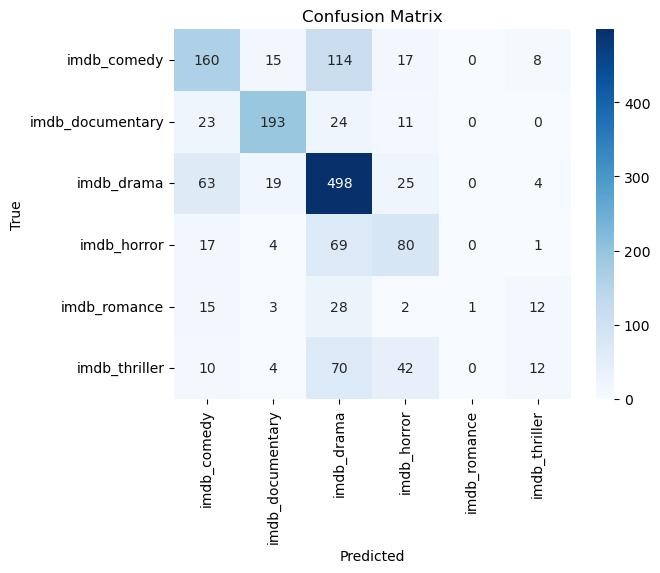

In [15]:
train_dataset = Dataset.from_dict({'text': train_texts, 'label': train_labels})
test_dataset = Dataset.from_dict({'text': test_texts, 'label': test_labels})

model_checkpoint = "sentence-transformers/all-MiniLM-L6-v2"
tokenizer = AutoTokenizer.from_pretrained(model_checkpoint)

def tokenize_function(examples):
    return tokenizer(examples["text"], padding="max_length", truncation=True, max_length=512)

train_dataset = train_dataset.map(tokenize_function, batched=True)
test_dataset = test_dataset.map(tokenize_function, batched=True)

train_dataset = train_dataset.remove_columns(["text"])
test_dataset = test_dataset.remove_columns(["text"])
train_dataset.set_format("torch")
test_dataset.set_format("torch")

model = AutoModelForSequenceClassification.from_pretrained(
    model_checkpoint,
    num_labels=len(label_encoder.classes_)
)

def compute_metrics(eval_pred):
    logits, labels = eval_pred
    predictions = np.argmax(logits, axis=-1)
    return {
        'precision': precision_score(labels, predictions, average='weighted'),
        'recall': recall_score(labels, predictions, average='weighted'),
        'accuracy': accuracy_score(labels, predictions),
        'f1': f1_score(labels, predictions, average='weighted')
    }

training_args = TrainingArguments(
    output_dir="./results",
    evaluation_strategy="epoch",
    save_strategy="epoch",
    learning_rate=1e-5,
    per_device_train_batch_size=4,
    per_device_eval_batch_size=4,
    num_train_epochs=10,
    weight_decay=0.01,
    load_best_model_at_end=True,
    metric_for_best_model="accuracy",
    fp16=True
)


trainer = Trainer(
    model=model,
    args=training_args,
    train_dataset=train_dataset,
    eval_dataset=test_dataset,
    tokenizer=tokenizer,
    compute_metrics=compute_metrics,
    callbacks=[EarlyStoppingCallback(early_stopping_patience=2)]
)

trainer.train()

predictions = trainer.predict(test_dataset)
y_preds = np.argmax(predictions.predictions, axis=1)

print(classification_report(test_labels, y_preds, target_names=label_encoder.classes_))
cm = confusion_matrix(test_labels, y_preds)
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', xticklabels=label_encoder.classes_, yticklabels=label_encoder.classes_)
plt.xlabel('Predicted')
plt.ylabel('True')
plt.title('Confusion Matrix')
plt.show()

In [16]:
model.save_pretrained("./results_synonym")
tokenizer.save_pretrained("./results_synonym")


('./results_synonym/tokenizer_config.json',
 './results_synonym/special_tokens_map.json',
 './results_synonym/vocab.txt',
 './results_synonym/added_tokens.json',
 './results_synonym/tokenizer.json')

## Random Insertion

In [8]:
def random_insertion(text, n=100):
    words = word_tokenize(text)
    new_words = words.copy()
    for _ in range(n):
        word = random.choice(new_words)
        syns = wordnet.synsets(word)
        if syns:
            synonym = syns[0].lemmas()[0].name()
            idx = random.randint(0, len(new_words)-1)
            new_words.insert(idx, synonym)
    return ' '.join(new_words)
    
# Augment underrepresented genres
thriller_romance_indices = train_labels[(train_labels == 'imdb_thriller') | (train_labels == 'imdb_romance')].index
thriller_romance_script = train_texts.loc[thriller_romance_indices].apply(random_insertion)

train_texts = pd.concat([train_texts, thriller_romance_script], ignore_index=True)
train_labels = pd.concat([train_labels, train_labels.loc[thriller_romance_indices]], ignore_index=True)

label_encoder = LabelEncoder()
train_labels = label_encoder.fit_transform(train_labels)
test_labels = label_encoder.transform(test_labels)


In [9]:
len(train_texts)

6882

Map: 100%|██████████| 1544/1544 [00:00<00:00, 3195.10 examples/s]
Some weights of BertForSequenceClassification were not initialized from the model checkpoint at sentence-transformers/all-MiniLM-L6-v2 and are newly initialized: ['classifier.bias', 'classifier.weight']
You should probably TRAIN this model on a down-stream task to be able to use it for predictions and inference.
/home/pierre/miniconda3/envs/ia/lib/python3.9/site-packages/transformers/training_args.py:1474: FutureWarning: `evaluation_strategy` is deprecated and will be removed in version 4.46 of 🤗 Transformers. Use `eval_strategy` instead
  warnings.warn(
huggingface/tokenizers: The current process just got forked, after parallelism has already been used. Disabling parallelism to avoid deadlocks...
To disable this warning, you can either:
	- Avoid using `tokenizers` before the fork if possible
	- Explicitly set the environment variable TOKENIZERS_PARALLELISM=(true | false)
2025-05-10 12:42:04.196860: I tensorflow/core/uti

Epoch,Training Loss,Validation Loss,Precision,Recall,Accuracy,F1
1,1.305000,1.245889,0.558710,0.542746,0.542746,0.471692
2,1.128100,1.132827,0.564013,0.597150,0.597150,0.570673
3,0.991600,1.108229,0.601090,0.609456,0.609456,0.581221
4,0.862800,1.143408,0.603310,0.591321,0.591321,0.588249
5,0.809100,1.173327,0.614527,0.605570,0.605570,0.595098


/home/pierre/miniconda3/envs/ia/lib/python3.9/site-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
/home/pierre/miniconda3/envs/ia/lib/python3.9/site-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))


                  precision    recall  f1-score   support

     imdb_comedy       0.53      0.49      0.51       314
imdb_documentary       0.78      0.81      0.79       251
      imdb_drama       0.62      0.78      0.69       609
     imdb_horror       0.46      0.50      0.48       171
    imdb_romance       0.75      0.15      0.25        61
   imdb_thriller       0.46      0.08      0.14       138

        accuracy                           0.61      1544
       macro avg       0.60      0.47      0.48      1544
    weighted avg       0.60      0.61      0.58      1544



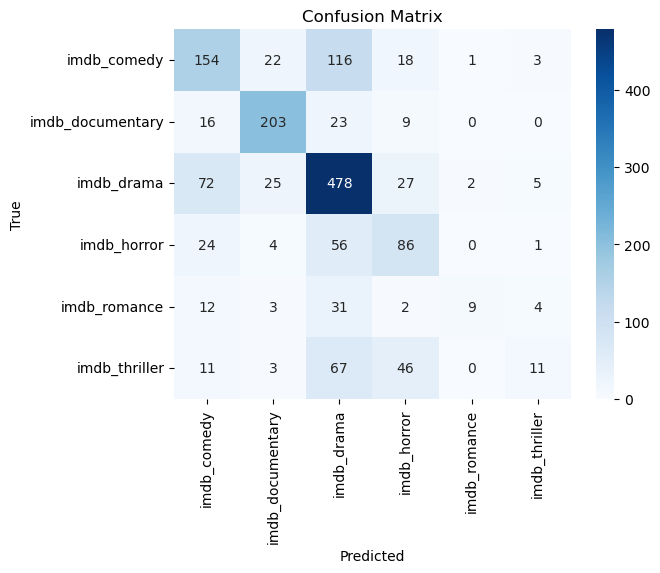

In [10]:
train_dataset = Dataset.from_dict({'text': train_texts, 'label': train_labels})
test_dataset = Dataset.from_dict({'text': test_texts, 'label': test_labels})

model_checkpoint = "sentence-transformers/all-MiniLM-L6-v2"
tokenizer = AutoTokenizer.from_pretrained(model_checkpoint)

def tokenize_function(examples):
    return tokenizer(examples["text"], padding="max_length", truncation=True, max_length=512)

train_dataset = train_dataset.map(tokenize_function, batched=True)
test_dataset = test_dataset.map(tokenize_function, batched=True)

train_dataset = train_dataset.remove_columns(["text"])
test_dataset = test_dataset.remove_columns(["text"])
train_dataset.set_format("torch")
test_dataset.set_format("torch")

model = AutoModelForSequenceClassification.from_pretrained(
    model_checkpoint,
    num_labels=len(label_encoder.classes_)
)

def compute_metrics(eval_pred):
    logits, labels = eval_pred
    predictions = np.argmax(logits, axis=-1)
    return {
        'precision': precision_score(labels, predictions, average='weighted'),
        'recall': recall_score(labels, predictions, average='weighted'),
        'accuracy': accuracy_score(labels, predictions),
        'f1': f1_score(labels, predictions, average='weighted')
    }

training_args = TrainingArguments(
    output_dir="./results_random_insertion",
    evaluation_strategy="epoch",
    save_strategy="epoch",
    learning_rate=1e-5,
    per_device_train_batch_size=4,
    per_device_eval_batch_size=4,
    num_train_epochs=10,
    weight_decay=0.01,
    load_best_model_at_end=True,
    metric_for_best_model="accuracy",
    fp16=True
)


trainer = Trainer(
    model=model,
    args=training_args,
    train_dataset=train_dataset,
    eval_dataset=test_dataset,
    tokenizer=tokenizer,
    compute_metrics=compute_metrics,
    callbacks=[EarlyStoppingCallback(early_stopping_patience=2)]
)

trainer.train()

predictions = trainer.predict(test_dataset)
y_preds = np.argmax(predictions.predictions, axis=1)

print(classification_report(test_labels, y_preds, target_names=label_encoder.classes_))
cm = confusion_matrix(test_labels, y_preds)
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', xticklabels=label_encoder.classes_, yticklabels=label_encoder.classes_)
plt.xlabel('Predicted')
plt.ylabel('True')
plt.title('Confusion Matrix')
plt.show()

In [11]:
model.save_pretrained("./results_random_insertion")
tokenizer.save_pretrained("./results_random_insertion")


('./results_random_insertion/tokenizer_config.json',
 './results_random_insertion/special_tokens_map.json',
 './results_random_insertion/vocab.txt',
 './results_random_insertion/added_tokens.json',
 './results_random_insertion/tokenizer.json')

## Sentence Shuffle

In [14]:
import random
from nltk.tokenize import sent_tokenize

def sentence_shuffle(text, shuffle_ratio=0.5):
    sentences = sent_tokenize(text)
    n = int(len(sentences) * shuffle_ratio)
    
    indices = list(range(len(sentences)))
    to_shuffle = random.sample(indices, n)
    
    shuffled = sentences.copy()
    shuffled_subset = [sentences[i] for i in to_shuffle]
    random.shuffle(shuffled_subset)
    
    for i, idx in enumerate(to_shuffle):
        shuffled[idx] = shuffled_subset[i]
    
    return ' '.join(shuffled)

# Augment underrepresented genres
thriller_romance_indices = train_labels[(train_labels == 'imdb_thriller') | (train_labels == 'imdb_romance')].index
thriller_romance_script = train_texts.loc[thriller_romance_indices].apply(sentence_shuffle)

train_texts = pd.concat([train_texts, thriller_romance_script], ignore_index=True)
train_labels = pd.concat([train_labels, train_labels.loc[thriller_romance_indices]], ignore_index=True)

label_encoder = LabelEncoder()
train_labels = label_encoder.fit_transform(train_labels)
test_labels = label_encoder.transform(test_labels)

In [15]:
len(train_texts)

6882

Map: 100%|██████████| 1544/1544 [00:00<00:00, 3193.65 examples/s]
Some weights of BertForSequenceClassification were not initialized from the model checkpoint at sentence-transformers/all-MiniLM-L6-v2 and are newly initialized: ['classifier.bias', 'classifier.weight']
You should probably TRAIN this model on a down-stream task to be able to use it for predictions and inference.
/home/pierre/miniconda3/envs/ia/lib/python3.9/site-packages/transformers/training_args.py:1474: FutureWarning: `evaluation_strategy` is deprecated and will be removed in version 4.46 of 🤗 Transformers. Use `eval_strategy` instead
  warnings.warn(
huggingface/tokenizers: The current process just got forked, after parallelism has already been used. Disabling parallelism to avoid deadlocks...
To disable this warning, you can either:
	- Avoid using `tokenizers` before the fork if possible
	- Explicitly set the environment variable TOKENIZERS_PARALLELISM=(true | false)


Epoch,Training Loss,Validation Loss,Precision,Recall,Accuracy,F1
1,1.387800,1.247100,0.453837,0.549223,0.549223,0.489955
2,1.239700,1.293756,0.535098,0.508420,0.508420,0.499741
3,1.127500,1.131985,0.596358,0.601036,0.601036,0.579639
4,1.006100,1.273052,0.580965,0.554404,0.554404,0.558228
5,0.915400,1.169314,0.620417,0.623705,0.623705,0.611382
6,0.824400,1.209224,0.607694,0.617228,0.617228,0.604124
7,0.730600,1.301761,0.611294,0.609456,0.609456,0.609153


/home/pierre/miniconda3/envs/ia/lib/python3.9/site-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
/home/pierre/miniconda3/envs/ia/lib/python3.9/site-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))


                  precision    recall  f1-score   support

     imdb_comedy       0.61      0.41      0.49       314
imdb_documentary       0.81      0.82      0.81       251
      imdb_drama       0.63      0.79      0.70       609
     imdb_horror       0.46      0.48      0.47       171
    imdb_romance       0.65      0.28      0.39        61
   imdb_thriller       0.44      0.36      0.40       138

        accuracy                           0.62      1544
       macro avg       0.60      0.52      0.54      1544
    weighted avg       0.62      0.62      0.61      1544



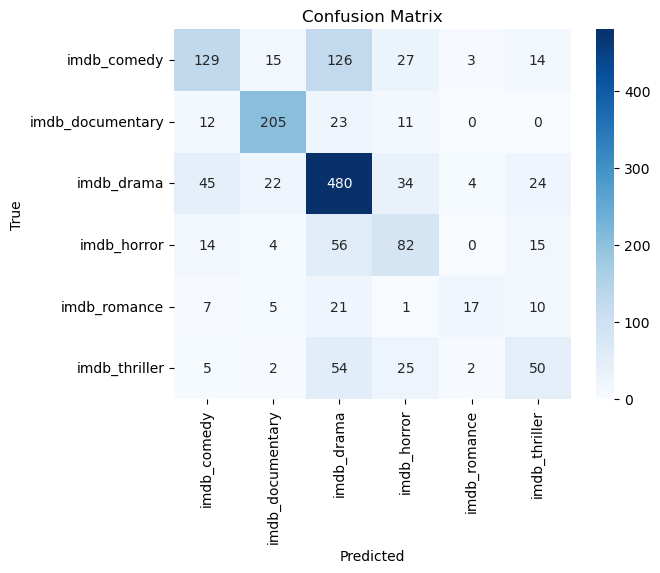

In [16]:
train_dataset = Dataset.from_dict({'text': train_texts, 'label': train_labels})
test_dataset = Dataset.from_dict({'text': test_texts, 'label': test_labels})

model_checkpoint = "sentence-transformers/all-MiniLM-L6-v2"
tokenizer = AutoTokenizer.from_pretrained(model_checkpoint)

def tokenize_function(examples):
    return tokenizer(examples["text"], padding="max_length", truncation=True, max_length=512)

train_dataset = train_dataset.map(tokenize_function, batched=True)
test_dataset = test_dataset.map(tokenize_function, batched=True)

train_dataset = train_dataset.remove_columns(["text"])
test_dataset = test_dataset.remove_columns(["text"])
train_dataset.set_format("torch")
test_dataset.set_format("torch")

model = AutoModelForSequenceClassification.from_pretrained(
    model_checkpoint,
    num_labels=len(label_encoder.classes_)
)

def compute_metrics(eval_pred):
    logits, labels = eval_pred
    predictions = np.argmax(logits, axis=-1)
    return {
        'precision': precision_score(labels, predictions, average='weighted'),
        'recall': recall_score(labels, predictions, average='weighted'),
        'accuracy': accuracy_score(labels, predictions),
        'f1': f1_score(labels, predictions, average='weighted')
    }

training_args = TrainingArguments(
    output_dir="./results_sentence_shuffle",
    evaluation_strategy="epoch",
    save_strategy="epoch",
    learning_rate=1e-5,
    per_device_train_batch_size=4,
    per_device_eval_batch_size=4,
    num_train_epochs=10,
    weight_decay=0.01,
    load_best_model_at_end=True,
    metric_for_best_model="accuracy",
    fp16=True
)


trainer = Trainer(
    model=model,
    args=training_args,
    train_dataset=train_dataset,
    eval_dataset=test_dataset,
    tokenizer=tokenizer,
    compute_metrics=compute_metrics,
    callbacks=[EarlyStoppingCallback(early_stopping_patience=2)]
)

trainer.train()

predictions = trainer.predict(test_dataset)
y_preds = np.argmax(predictions.predictions, axis=1)

print(classification_report(test_labels, y_preds, target_names=label_encoder.classes_))
cm = confusion_matrix(test_labels, y_preds)
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', xticklabels=label_encoder.classes_, yticklabels=label_encoder.classes_)
plt.xlabel('Predicted')
plt.ylabel('True')
plt.title('Confusion Matrix')
plt.show()

In [17]:
model.save_pretrained("./results_sentence_shuffle")
tokenizer.save_pretrained("./results_sentence_shuffle")


('./results_sentence_shuffle/tokenizer_config.json',
 './results_sentence_shuffle/special_tokens_map.json',
 './results_sentence_shuffle/vocab.txt',
 './results_sentence_shuffle/added_tokens.json',
 './results_sentence_shuffle/tokenizer.json')